In [18]:
from google.colab import files
uploaded = files.upload()

Saving New data z.zip to New data z (6).zip


In [19]:
from zipfile import ZipFile

with ZipFile("New data z.zip", 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [20]:
import os

print(os.listdir("dataset"))

['New data']


In [21]:
import os

path = "dataset/New data"

print("Number of images:", len(os.listdir(path)))

Number of images: 1088


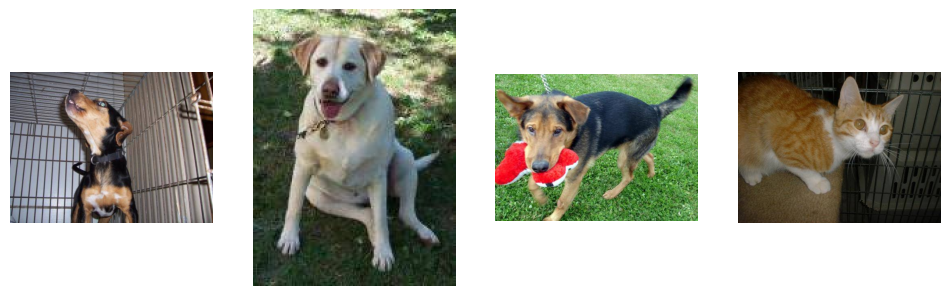

In [22]:
import os
import cv2
import matplotlib.pyplot as plt

path = "dataset/New data"

files = os.listdir(path)

plt.figure(figsize=(12,6))

for i in range(4):
    img = cv2.imread(os.path.join(path, files[i]))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

Dataset Shape: (1088, 1024)
Accuracy: 50.92 %


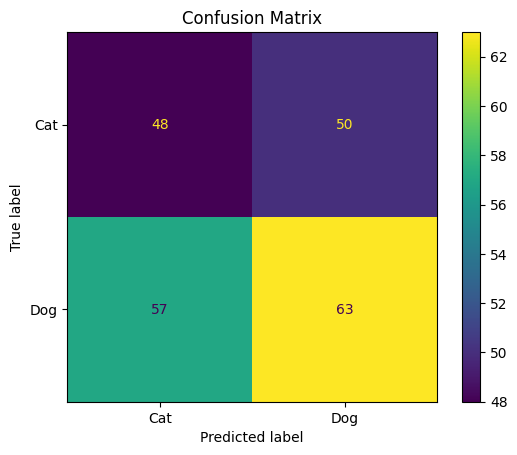

In [23]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Lists to store data
data = []
labels = []

# Path to images
path = "dataset/New data"

# Read images
for file in os.listdir(path):

    img_path = os.path.join(path, file)

    img = cv2.imread(img_path)

    # Skip if image cannot be read
    if img is None:
        continue

    # Resize image (faster training)
    img = cv2.resize(img, (32, 32))

    # Convert to grayscale
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Flatten image into 1D array
    data.append(img.flatten())

    # Labels
    if file.lower().startswith("cat"):
        labels.append(0)  # Cat
    else:
        labels.append(1)  # Dog

# Convert to numpy arrays
X = np.array(data)
y = np.array(labels)

print("Dataset Shape:", X.shape)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# SVM Model
svm = SVC(kernel='linear')

# Train
svm.fit(X_train, y_train)

# Predict
y_pred = svm.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", round(accuracy * 100, 2), "%")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Cat", "Dog"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()